In [1]:
# Import dependencies

import numpy as np
from tqdm import tqdm
import multiprocessing as mp
import os
from PIL import Image
import rasterio as rio
import matplotlib.pyplot as plt
import glob
import random
from collections import Counter
import pandas as pd


# Patches and their corresponding AIS labels

In [2]:
# Define Data Path:

head_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"
# head_dir = "/mnt/c/Users/vn25612/OneDrive - University of Bristol/NovaSARNet/"

In [3]:
# A list to hold paths of 'ship_patches' directories

patch_dirs = []

# Walk through the directory tree
for root, dirs, files in os.walk(head_dir):
    # Check if this folder has no subfolders (i.e., it's a leaf folder)
    if not dirs:
        # Check if the current folder itself is named 'ship_patches'
        if os.path.basename(root) == 'ship_patches':
            patch_dirs.append(root)


# Print the results
patch_dirs


['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222538_HH_1/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222549_HH_3/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222555_HH_4/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222600_HH_5/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676_grd_13_240118_082042_HH_2/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_g

In [ ]:
# # # Copy Updated AIS.csv from OneDrive:


# import os
# import shutil

# # Target directory
# target_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"


# # Copy files from each source directory to the target directory
# for patch_dirii in patch_dirs:
    
#     # Copy AIS.csv:
#     ais_target_dirii = f"{target_dir}{'/'.join(patch_dirii.split('/')[-4:-1])}"
#     shutil.copy2(f"{'/'.join(patch_dirii.split('/')[:-1])}/AIS.csv", ais_target_dirii)




In [ ]:
# # # # Copy Patches and AIS.csv to other location (OneDrive):


# import os
# import shutil

# # Target directory:
# target_dir = '/mnt/c/Users/vn25612/OneDrive - University of Bristol/NovaSARNet/'
# # target_dir = '/mnt/Z/Data-Bris/NASTaR/'

# # Create target directory if it doesn't exist
# os.makedirs(target_dir, exist_ok=True)

# # Copy files from each source directory to the target directory
# for patch_dirii in patch_dirs:
#     # Copy Ship Patchces:
#     patch_target_dirii = f"{target_dir}{'/'.join(patch_dirii.split('/')[-4:])}"
#     os.makedirs(patch_target_dirii, exist_ok=True)
#     for filenameii in os.listdir(patch_dirii):
#         src_fileii = os.path.join(patch_dirii, filenameii)
#         if os.path.isfile(src_fileii):
#             shutil.copy2(src_fileii, patch_target_dirii)
    
#     # Copy Ship Patchces UINT8:
#     patch_target_dirii = f"{target_dir}{'/'.join(patch_dirii.split('/')[-4:])}_uint8"
#     os.makedirs(patch_target_dirii, exist_ok=True)
#     patch_diru8ii = f"{patch_dirii}_uint8"
#     for filenameii in os.listdir(patch_diru8ii):
#         src_fileii = os.path.join(patch_diru8ii, filenameii)
#         if os.path.isfile(src_fileii):
#             shutil.copy2(src_fileii, patch_target_dirii)
    
#     # Copy AIS.csv:
#     ais_target_dirii = f"{target_dir}{'/'.join(patch_dirii.split('/')[-4:-1])}"
#     shutil.copy2(f"{'/'.join(patch_dirii.split('/')[:-1])}/AIS.csv", ais_target_dirii)




In [ ]:
# Add Wake Potential column to AIS.csv files:

# for p_dirsii in patch_dirs: 
#     # Walk through the directory and find all .tif files
#     for root, dirs, files in os.walk(p_dirsii):
#         head_dirii = f"{'/'.join(root.split('/')[:-1])}/"
#         AIS_dirii = f"{head_dirii}AIS.csv"
        
#         AIS_dfii = pd.read_csv(AIS_dirii)
        
#         if ('Wake Potential' in AIS_dfii.columns) == False:
#             wake_idxii= np.where(AIS_dfii['SOG'].to_numpy() > 1)[0] # Only consider ships with SOG > 1 knot (to avoid stationary objects)
#             AIS_dfii['Wake Potential'] = ""
#             AIS_dfii.loc[wake_idxii, 'Wake Potential'] = 1
#             AIS_dfii.to_csv(AIS_dirii, index=False)
        
#         if ('Wake Quality' in AIS_dfii.columns) == False:
#             AIS_dfii['Wake Quality'] = ""
#             AIS_dfii.to_csv(AIS_dirii, index=False)

#         AIS_dfii.to_csv(AIS_dirii, index=False)

In [ ]:
# # Add a column to AIS.csv files:
# col_name = 'Quality'
# before_col_name = 'Shoreline' # None # Add column after this column

# for p_dirsii in patch_dirs: 
#     # Walk through the directory and find all .tif files
#     for root, dirs, files in os.walk(p_dirsii):
#         head_dirii = f"{'/'.join(root.split('/')[:-1])}/"
#         AIS_dirii = f"{head_dirii}AIS.csv"
        
#         AIS_dfii = pd.read_csv(AIS_dirii)
        
#         if (col_name in AIS_dfii.columns) == False:
#             if before_col_name != None:
#                 idx = AIS_dfii.columns.get_loc(before_col_name) + 1 
#                 AIS_dfii.insert(idx, col_name, "")
#             else:
#                 AIS_dfii[col_name] = ""
#                 AIS_dfii.to_csv(AIS_dirii, index=False)

#         AIS_dfii.to_csv(AIS_dirii, index=False)

In [ ]:
# # Quality Control based on Proximity of Ships:

# from pyproj import Geod
# # 
# dist_thresh = 125  # meters
# dist_thresh = 150  # meters



# geod = Geod(ellps="WGS84")# Initialize Geod for geodesic calculations on WGS84 ellipsoid

# for p_dirsii in patch_dirs: 
#     # Walk through the directory 
#     for root, dirs, files in os.walk(p_dirsii):
#         head_dirii = f"{'/'.join(root.split('/')[:-1])}/"
#         AIS_dirii = f"{head_dirii}AIS.csv"
#         print(f"Processing AIS file: {AIS_dirii}")
        
#         AIS_dfii = pd.read_csv(AIS_dirii)


#         Lat = AIS_dfii['Latitude'].to_numpy()
#         Lon = AIS_dfii['Longitude'].to_numpy()
#         quality   = np.float32(AIS_dfii['Quality'].to_numpy())
#         quality[quality==9]=np.nan # Reset duplicates to nan for processing
#         ship_name = AIS_dfii['Ship type']
#         shoreline = AIS_dfii['Shoreline']
#         N_p = len(Lat)

#         for ii in range(N_p):
            
#             lonii, latii = Lon[ii], Lat[ii]

#             if shoreline[ii]== 'inshore': # Check only inshore ships
#                 for jj in range(ii+1, N_p):
#                     if shoreline[jj] == 'inshore':
#                         if ship_name[ii] != ship_name[jj] and (ship_name[jj] != "Other" and ship_name[jj] != "Undefined"): # if Labels are different
#                             lonjj, latjj = Lon[jj], Lat[jj]
#                             _, _, distance_ij = geod.inv( lonii, latii, lonjj, latjj ) # geodesic distance in meters
#                             if distance_ij < dist_thresh:
#                                 quality[ii] = 0  # Mark as Low Quality
#                                 quality[jj] = 0  # Mark as Low Quality
            
            
#             if quality[ii] == 0 or quality[ii] == 9 or ship_name[ii] == "Undefined":
#                 # print(f"Skipping index ii {ii} as it is already marked low quality {quality[ii]}.")
#                 pass
            
#             else:

#                 for jj in range(ii+1, N_p):
#                     if quality[jj] == 0 or quality[jj] == 9:
#                         # print(f"Skipping index jj {jj} as it is already marked low quality or duplicate {quality[jj]}.")
#                         pass
#                     else:
#                         if ship_name[ii] == ship_name[jj] or ship_name[jj] == "Other" or ship_name[jj] == "Undefined" :
#                             lonjj, latjj = Lon[jj], Lat[jj]
#                             _, _, distance_ij = geod.inv( lonii, latii, lonjj, latjj ) # geodesic distance in meters
#                             if distance_ij < dist_thresh:
#                                 if ship_name[ii] == ship_name[jj]:
#                                     quality[jj] = 9  # Mark as duplicate (9) 
#                                     print(f"Marking index {jj} as duplicate of index {ii} with distance {distance_ij:.2f} meters.")
#                                 else:
#                                     quality[jj] = 0  # Mark as Low Quality
#                                 AIS_dfii.loc[jj, 'Quality'] = quality[jj]
                                
#         AIS_dfii.to_csv(AIS_dirii, index=False)


Processing AIS file: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222538_HH_1/AIS.csv
Processing AIS file: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/AIS.csv
Processing AIS file: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222549_HH_3/AIS.csv
Processing AIS file: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222555_HH_4/AIS.csv
Marking index 1 as duplicate of index 0 with distance 28.40 meters.
Processing AIS file: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222600_HH_5/AIS.csv
Processing AIS file: /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_2401

In [ ]:
# # Delete all directories named TARGET_NAME under HEAD_DIR
# from pathlib import Path
# import shutil
# import stat

# # ====== CONFIGURE THESE ======
# HEAD_DIR = Path(head_dir)  # <-- change this
# TARGET_NAME = "wake_patches_512x512_new"  # <-- change this
# DRY_RUN = False#True            # set to True first to preview without deleting
# CASE_INSENSITIVE = False  # set to True if you want case-insensitive matching
# SKIP_SYMLINKS = True      # set False if you want to delete symlinked dirs too
# # =============================

# def make_writable(p: Path):
#     """Ensure a file/dir is writable (helps remove read-only items)."""
#     try:
#         p.chmod(p.stat().st_mode | stat.S_IWRITE)
#     except Exception:
#         pass

# def on_rm_error(func, path, exc_info):
#     """
#     Handler for shutil.rmtree when it hits a permission error.
#     Tries to make the file writable and retry.
#     """
#     try:
#         p = Path(path)
#         make_writable(p)
#         func(path)
#     except Exception as e:
#         print(f"ERROR: cannot delete {path}: {e}")

# def find_matches(root: Path):
#     """Return all directories in the tree whose name matches TARGET_NAME."""
#     if CASE_INSENSITIVE:
#         target = TARGET_NAME.lower()
#         return [p for p in root.rglob("*") if p.is_dir() and p.name.lower() == target]
#     else:
#         return [p for p in root.rglob("*") if p.is_dir() and p.name == TARGET_NAME]

# def main():
#     if not HEAD_DIR.exists():
#         raise SystemExit(f"Head directory does not exist: {HEAD_DIR}")

#     matches = find_matches(HEAD_DIR)
#     if not matches:
#         print(f"No directories named '{TARGET_NAME}' found under {HEAD_DIR}")
#         return

#     print(f"Found {len(matches)} directories named '{TARGET_NAME}':")
#     for d in matches:
#         print(f"  - {d}")

#     if DRY_RUN:
#         print("DRY RUN: Nothing deleted. Set DRY_RUN = False to proceed.")
#         return

#     deleted = 0
#     skipped = 0
#     for d in matches:
#         if SKIP_SYMLINKS and d.is_symlink():
#             print(f"SKIP symlink: {d}")
#             skipped += 1
#             continue

#         print(f"DELETE: {d}")
#         try:
#             shutil.rmtree(d, onerror=on_rm_error)
#             deleted += 1
#         except PermissionError:
#             print(f"ERROR: Permission denied deleting {d}")
#             skipped += 1
#         except OSError as e:
#             print(f"ERROR: Could not delete {d}: {e}")
#             skipped += 1

#     print(f"Done. Deleted: {deleted}, Skipped: {skipped}")

# if __name__ == "__main__":
#     main()


Found 463 directories named 'wake_patches_512x512_new':
  - /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/wake_patches_512x512_new
  - /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222549_HH_3/wake_patches_512x512_new
  - /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222600_HH_5/wake_patches_512x512_new
  - /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676_grd_13_240118_082042_HH_2/wake_patches_512x512_new
  - /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676_grd_13_240118_082047_HH_3/wake_patches_512x512_new
  - /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51676_grd_240118_082036_HH/NovaSAR_01_51676

In [9]:
"/".join(pathii[:-1])

'/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222538_HH_1'

In [12]:
f"{head_dir_copy}/{pathii[-2]}/AIS.csv"

'/mnt/c/Users/vn25612/OneDrive - University of Bristol/NovaSARNet/Data//NovaSAR_01_51481_grd_13_240111_222538_HH_1/AIS.csv'

In [ ]:
# A list to hold paths of 'ship_patches' directories

import os
import shutil

target_names = {
    'ship_patches',
    'ship_patches_uint8',
    'wake_patches_512x512',
    'wake_patches_uint8_512x512',
    'wake_patches',
    'wake_patches_uint8',
}

head_dir_copy = "/mnt/c/Users/vn25612/OneDrive - University of Bristol/NovaSARNet/Data/"
patch_dirs = []
for root, dirs, files in os.walk(head_dir):
    if os.path.basename(root) in target_names:
        patch_dirs.append(root)

        pathii = root.split('/')
        sub_pathii = "/".join(pathii[-2:])
        pathcopyii = f"{head_dir_copy}{sub_pathii}"
        
        sub_pathii_AIS = "/".join(pathii[:-1])
        AIS_pathii     = f"/{sub_pathii_AIS}/AIS.csv"
        pathcopyii_AIS = f"{head_dir_copy}/{pathii[-2]}/AIS.csv"

        os.makedirs(pathcopyii, exist_ok=True)
        
        # Copy AIS.csv
        shutil.copy2(AIS_pathii, pathcopyii_AIS)
        
        # Copy patches
        for filenameii in os.listdir(root):
            src_fileii = os.path.join(root, filenameii)
            if os.path.isfile(src_fileii):
                shutil.copy2(src_fileii, pathcopyii)



# Print the results
patch_dirs


['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222538_HH_1/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222538_HH_1/ship_patches_uint8',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/ship_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/ship_patches_uint8',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/wake_patches',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb23/NovaSAR_01_51481_grd_240111_222538_HH/NovaSAR_01_51481_grd_13_240111_222543_HH_2/wake_patches_512x512',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Feb2

In [5]:
# AIS_df: A dataframe to hold all AIS data 
# tif_dir: A list to hold paths of all the .tif files in the 'ship_patches' directories

import re
tif_dir = []
AIS_df  = []
for p_dirsii in patch_dirs:
    tif_dir.append([])  # Add the directory itself to the list
    # Walk through the directory and find all .tif files
    for root, dirs, files in os.walk(p_dirsii):
        head_dirii = f"{'/'.join(root.split('/')[:-1])}/"
        AIS_dirii = f"{head_dirii}AIS.csv"
        AIS_dfii = pd.read_csv(AIS_dirii)     
        AIS_df.append(AIS_dfii)
        
        scene_pathii = head_dirii+[ f for f in os.listdir(head_dirii) if 'corrected' in f ][0]
        AIS_df[-1]['Scene path'] = scene_pathii
        metadata_pathii = scene_pathii[:-22]+'metadata.xml'
        AIS_df[-1]['Metadata path'] = metadata_pathii

        files = sorted(files, key=lambda x: int(re.search(r'patch_(\d+)', x).group(1)))
        for file in files:
            if file.lower().endswith('.tif'):         
                full_pathii = os.path.join( root, file )
                tif_dir[-1].append( full_pathii )

AIS_df  = pd.concat(AIS_df, ignore_index=True)
tif_dir = [item for sublist in tif_dir for item in sublist]
print(f"Found {len(tif_dir)} patches in {len(patch_dirs)} directories.")

Found 3415 patches in 624 directories.


In [5]:
AIS_df

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Patch_name,Dist_to_land,Shoreline,Quality,Wake Potential,Wake Quality,Scene path,Metadata path,Unnamed: 32,Unnamed: 31
0,11/01/2024 22:25:34,Base Station,2190049,55.735817,10.918782,Unknown value,NaN,NaN,NaN,NaN,...,NovaSAR_01_51481_grd_13_240111_222538_HH_1_pat...,927.275478,offshore,NaN,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
1,11/01/2024 22:25:35,Class A,219003966,55.675625,11.102063,Under way using engine,0.0,0.0,351.0,344.0,...,NovaSAR_01_51481_grd_13_240111_222538_HH_1_pat...,1.419551,inshore,NaN,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
2,11/01/2024 22:25:42,Class A,219023833,55.677365,11.082657,Under way using engine,0.0,0.0,101.1,92.0,...,NovaSAR_01_51481_grd_13_240111_222538_HH_1_pat...,4.519244,inshore,NaN,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
3,11/01/2024 22:25,Class A,219543000,55.619317,10.792550,Under way using engine,0.0,15.7,158.8,160.0,...,NovaSAR_01_51481_grd_13_240111_222543_HH_2_pat...,11248.335833,offshore,NaN,1.0,1.0,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
4,11/01/2024 22:25,Class B,219003038,55.059985,10.616735,Unknown value,NaN,0.0,NaN,NaN,...,NovaSAR_01_51481_grd_13_240111_222549_HH_3_pat...,24.686231,inshore,0.0,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,05/06/2024 22:03,Class A,636022446,54.964667,13.826333,Under way using engine,-2.9,12.1,73.0,72.0,...,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,3877.721031,offshore,NaN,1.0,0.0,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
3411,05/06/2024 22:03,Class A,230617000,54.985422,13.620405,Under way using engine,2.9,17.5,250.0,250.0,...,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,1567.210703,offshore,NaN,1.0,1.0,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
3412,05/06/2024 22:03,Class A,232026551,54.953547,13.567260,Under way using engine,0.0,10.4,252.2,255.0,...,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,5115.630310,offshore,NaN,1.0,1.0,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN
3413,05/06/2024 22:03,AtoN,992111808,54.845067,13.584312,Unknown value,NaN,NaN,NaN,NaN,...,NovaSAR_01_54685_grd_13_240605_220318_HH_4_pat...,17191.805560,offshore,NaN,NaN,NaN,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_...,NaN,NaN


In [6]:
ship_name = AIS_df['Ship type'].tolist()
shoreline = AIS_df['Shoreline'].tolist()
quality   = AIS_df['Quality'].tolist()

In [7]:
# Extract unique Ship names and their counts:

# from collections import Counter
# # Count frequency of each prefix
# ship_name_counts = Counter(ship_name)
# ship_name_counts

AIS_df['Ship type'].value_counts()

Ship type
Fishing                  769
Cargo                    593
Passenger                389
Tanker                   265
Sailing                  187
Undefined                168
Pleasure                 158
Tug                      146
Other                    145
Dredging                 119
Pilot                    114
SAR                       99
HSC                       76
Military                  60
Law enforcement           38
Port tender               26
Reserved                  18
Towing                    12
Diving                     8
Spare 1                    7
Towing long/wide           5
Anti-pollution             4
Not party to conflict      4
Medical                    3
WIG                        2
Name: count, dtype: int64

In [58]:
Export_path = "DatasetStat_Charts"
if not os.path.exists(Export_path):
    os.makedirs(Export_path)

# Stats for Ship Patches

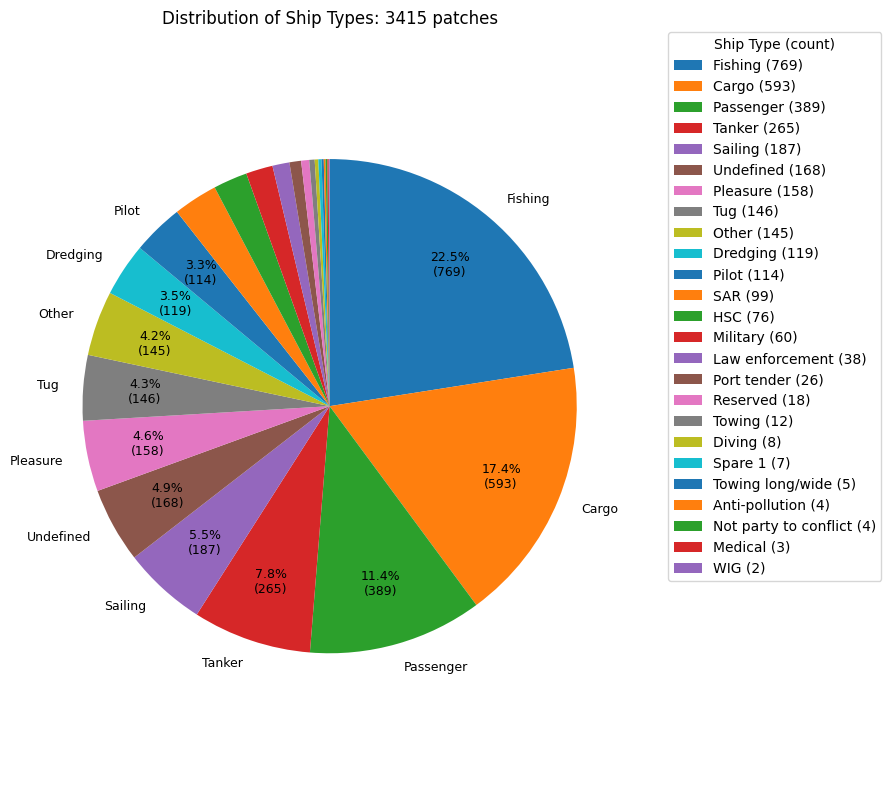

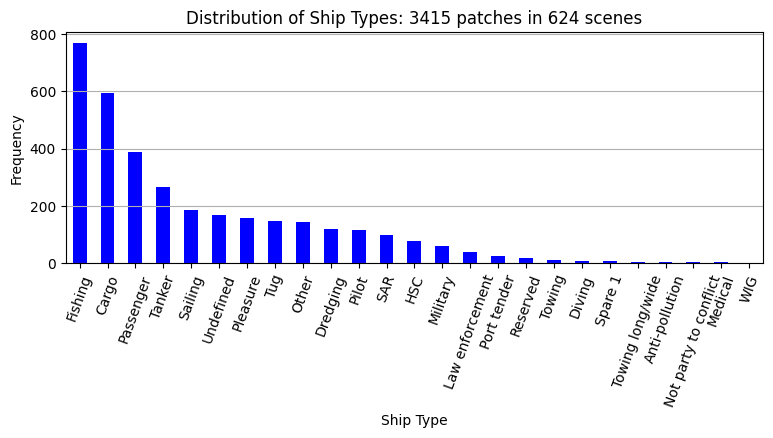

In [79]:
# === Config: what counts as "small" (hidden on the pie, still shown in legend) ===
MIN_PCT = 3.0   # hide labels/percentages for slices smaller than this percentage

# Get counts
counts = AIS_df['Ship type'].value_counts()
names = counts.index.to_list()
values = counts.values
total = values.sum()
pcts = values / total * 100.0

# Decide which slices are "large enough" to label on the pie
mask = pcts >= MIN_PCT

# Fallback: if none meets the threshold, label at least the largest slice
if not mask.any():
    # mark only the argmax as True
    mask[np.argmax(pcts)] = True

# Build labels for wedges: show name only for large slices
labels = [name if m else '' for name, m in zip(names, mask)]

# Autopct that shows % and count only for large slices
any_large = mask.any()
max_pct = float(pcts.max()) if len(pcts) else 0.0
EPS = 1e-9

def autopct_if_large(pct):
    # Show text only if this slice is considered "large"
    if any_large:
        if pct + EPS < MIN_PCT:
            return ''
    else:
        # Fallback case (shouldn't happen with mask fix, but kept for safety)
        if pct + EPS < max_pct:
            return ''
    val = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({val})'

fig, ax = plt.subplots(figsize=(9, 8))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct=autopct_if_large,
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    textprops={'fontsize': 9}
)

ax.set_title(f'Distribution of Ship Types: {len(tif_dir)} patches')
ax.axis('equal')  # keep it circular

# === Legend: include ALL categories, regardless of size ===
legend_labels = [f'{n} ({v})' for n, v in zip(names, values)]
ax.legend(
    wedges, legend_labels,
    title='Ship Type (count)',
    bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.
)

plt.tight_layout()
plt.savefig(f"{Export_path}/ShipType_Distribution_AllPatches_PieChart.jpg", dpi=400)

plt.figure()
AIS_df['Ship type'].value_counts().plot(kind='bar', figsize=(9, 3), color='blue')
plt.title(f'Distribution of Ship Types: {len(tif_dir)} patches in {len(patch_dirs)} scenes')
plt.xlabel('Ship Type')
plt.ylabel('Frequency')
plt.xticks(rotation=70)
plt.grid(axis='y')
plt.savefig(f"{Export_path}/ShipType_Distribution_AllPatches_BarChart.jpg", dpi=400)

## Only High Quality images (Inshore and OffShore)

In [9]:
# Remove inshore patches and low quality patches:
quality0 = np.array(quality)
quality0[quality0==9]=0

tif_dir2 = [tifii for tifii, shoreii,qii in zip(tif_dir, shoreline, quality0) if qii !=0]

AIS_df2 = AIS_df[ (AIS_df['Quality'] != 0) & (AIS_df['Quality'] != 9) ]
AIS_df2.reset_index(drop=True, inplace=True)

print(f"Found {len(AIS_df2)} High Quality images --> Removed low quality patches.")

Found 1891 High Quality images --> Removed low quality patches.


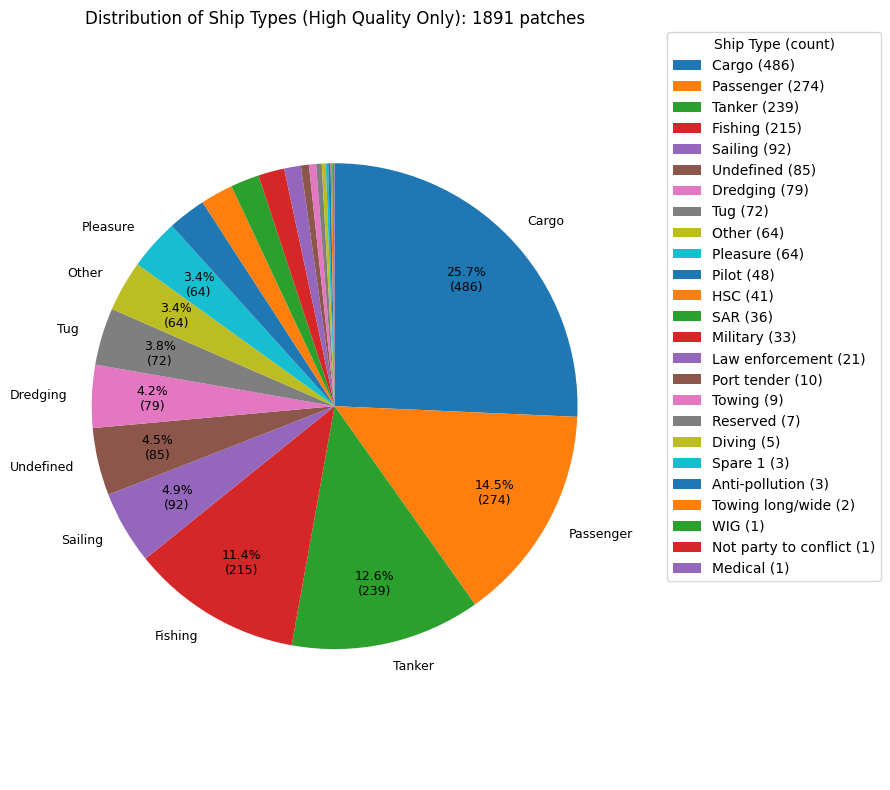

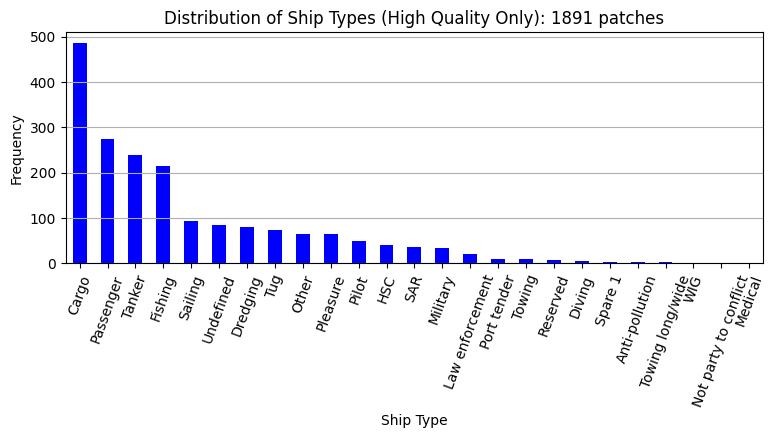

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Config: what counts as "small" (hidden on the pie, still shown in legend) ===
MIN_PCT = 3.0   # hide labels/percentages for slices smaller than this percentage

# Get counts
counts = AIS_df2['Ship type'].value_counts()
names = counts.index.to_list()
values = counts.values
total = values.sum()
pcts = values / total * 100.0

# Decide which slices are "large enough" to label on the pie
mask = pcts >= MIN_PCT

# Fallback: if none meets the threshold, label at least the largest slice
if not mask.any():
    # mark only the argmax as True
    mask[np.argmax(pcts)] = True

# Build labels for wedges: show name only for large slices
labels = [name if m else '' for name, m in zip(names, mask)]

# Autopct that shows % and count only for large slices
any_large = mask.any()
max_pct = float(pcts.max()) if len(pcts) else 0.0
EPS = 1e-9

def autopct_if_large(pct):
    # Show text only if this slice is considered "large"
    if any_large:
        if pct + EPS < MIN_PCT:
            return ''
    else:
        # Fallback case (shouldn't happen with mask fix, but kept for safety)
        if pct + EPS < max_pct:
            return ''
    val = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({val})'

fig, ax = plt.subplots(figsize=(9, 8))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct=autopct_if_large,
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    textprops={'fontsize': 9}
)

ax.set_title(f'Distribution of Ship Types (High Quality Only): {len(tif_dir2)} patches')
ax.axis('equal')  # keep it circular

# === Legend: include ALL categories, regardless of size ===
legend_labels = [f'{n} ({v})' for n, v in zip(names, values)]
ax.legend(
    wedges, legend_labels,
    title='Ship Type (count)',
    bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.
)

plt.tight_layout()

plt.figure()
AIS_df2['Ship type'].value_counts().plot(kind='bar', figsize=(9, 3), color='blue')
plt.title(f'Distribution of Ship Types (High Quality Only): {len(tif_dir2)} patches')
plt.xlabel('Ship Type')
plt.ylabel('Frequency')
plt.xticks(rotation=70)
plt.grid(axis='y')

plt.savefig(f"{Export_path}/ShipType_Distribution_HQPatches_BarChart.jpg", dpi=400)

In [15]:
# Extract unique Ship names and their counts:

AIS_df2['Ship type'].value_counts()

Ship type
Cargo                    486
Passenger                274
Tanker                   239
Fishing                  215
Sailing                   92
Undefined                 85
Dredging                  79
Tug                       72
Other                     64
Pleasure                  64
Pilot                     48
HSC                       41
SAR                       36
Military                  33
Law enforcement           21
Port tender               10
Towing                     9
Reserved                   7
Diving                     5
Spare 1                    3
Anti-pollution             3
Towing long/wide           2
WIG                        1
Not party to conflict      1
Medical                    1
Name: count, dtype: int64

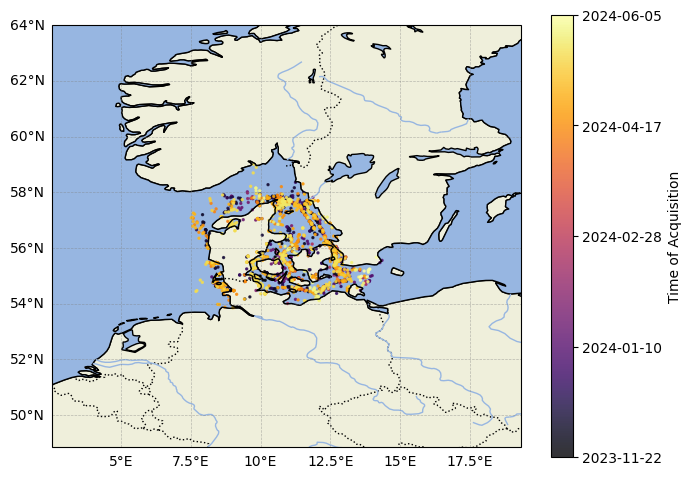

In [139]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Sample data
data = {
    'latitude': AIS_df2['Latitude'].tolist(),
    'longitude': AIS_df2['Longitude'].tolist(),
    'timestamp': pd.to_datetime(AIS_df2['# Timestamp'], format='mixed', dayfirst=True).tolist()
}


# Create DataFrame
df = pd.DataFrame(data)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', dayfirst=True)

# Normalize timestamps
time_numeric = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

# Zoom extent
lat_min, lat_max = df['latitude'].min() - 5, df['latitude'].max() + 5
lon_min, lon_max = df['longitude'].min() - 5, df['longitude'].max() + 5

# Plot
fig = plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAKES, edgecolor='black')
ax.add_feature(cfeature.RIVERS)

# Scatter plot
sc = ax.scatter(df['longitude'], df['latitude'], c=time_numeric, alpha=0.8, cmap='inferno', s=2, transform=ccrs.PlateCarree())

# Colorbar with datetime labels
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
timestamps = pd.date_range(start=df['timestamp'].min(), end=df['timestamp'].max(), periods=5)
tick_values = (timestamps - df['timestamp'].min()).total_seconds()
cbar.set_ticks(tick_values)
# cbar.set_ticklabels([ts.strftime('%Y-%m-%d %H:%M') for ts in timestamps])
cbar.set_ticklabels([ts.strftime('%Y-%m-%d') for ts in timestamps])
cbar.set_label('Time of Acquisition')

# Lat/lon ticks
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# plt.title('Zoomed Geographic Distribution of Points by Time of Acquisition')
plt.tight_layout()
plt.savefig(f"{Export_path}/GeoLocation_AISPoints.jpg", dpi=400)
# plt.show()

## Only High Quality and InShore images

In [142]:
# Remove inshore patches and low quality patches:
quality0 = np.array(quality)
quality0[quality0==9]=0

tif_dir3 = [tifii for tifii, shoreii,qii in zip(tif_dir, shoreline, quality0) if (shoreii == 'inshore' and qii !=0)]

AIS_df3 = AIS_df[AIS_df['Shoreline'] == 'inshore']
AIS_df3 = AIS_df3[ (AIS_df3['Quality'] != 0) & (AIS_df3['Quality'] != 9) ]

AIS_df3.reset_index(drop=True, inplace=True)


print(f"Found {len(AIS_df3)} High Quality inshore --> Removed offshore patches.")

Found 703 High Quality inshore --> Removed offshore patches.


In [163]:
Shtype = [  'Cargo', 'Tanker', 'Fishing', 'Passenger', 'Tug', 'Sailing']

Ship_type3 = AIS_df3['Ship type'].to_list()

for shtii in Shtype:
    tif_dir_class = [tifii for tifii, typeii in zip(tif_dir3, Ship_type3) if (typeii == shtii)]
    tif_dir_class

    if not os.path.exists(f"{head_dir}Inshore_HighQuality_Patches/"):
        os.mkdir(f"{head_dir}Inshore_HighQuality_Patches/")
    copypath = f"{head_dir}Inshore_HighQuality_Patches/{shtii}/"

    if not os.path.exists(copypath):
        os.mkdir(copypath)
    import shutil
    for tifii in tif_dir_class:
        filenameii = tifii.split('/')[-1]
        tifii = tifii.replace('ship_patches', 'ship_patches_uint8')
        tifii = tifii[:-4] + '_uint8.tif'

        shutil.copy2(tifii, f"{copypath}{filenameii}")

In [160]:

tifii = tifii.replace('ship_patches', 'ship_patches_uint8')
tifii

'/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_54503_grd_240530_081900_HH/NovaSAR_01_54503_grd_13_240530_081945_HH_9/ship_patches_uint8/NovaSAR_01_54503_grd_13_240530_081945_HH_9_patch_1_Fishing.tif'

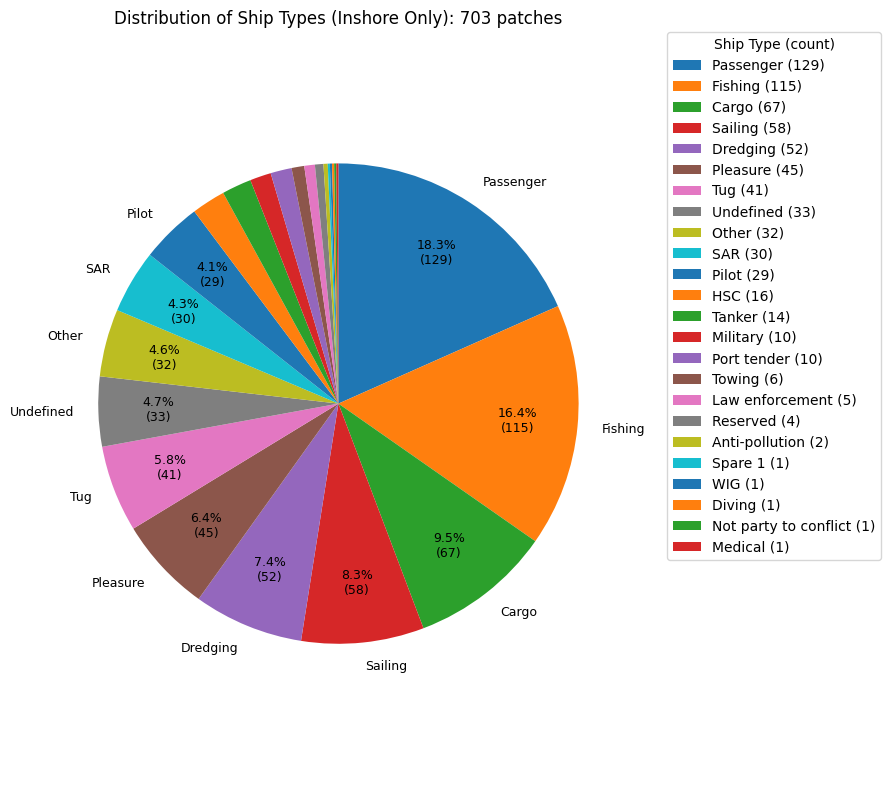

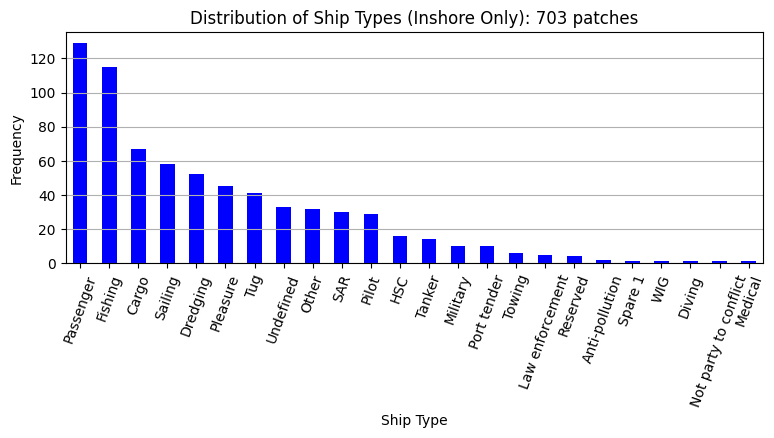

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Config: what counts as "small" (hidden on the pie, still shown in legend) ===
MIN_PCT = 3.0   # hide labels/percentages for slices smaller than this percentage

# Get counts
counts = AIS_df3['Ship type'].value_counts()
names = counts.index.to_list()
values = counts.values
total = values.sum()
pcts = values / total * 100.0

# Decide which slices are "large enough" to label on the pie
mask = pcts >= MIN_PCT

# Fallback: if none meets the threshold, label at least the largest slice
if not mask.any():
    # mark only the argmax as True
    mask[np.argmax(pcts)] = True

# Build labels for wedges: show name only for large slices
labels = [name if m else '' for name, m in zip(names, mask)]

# Autopct that shows % and count only for large slices
any_large = mask.any()
max_pct = float(pcts.max()) if len(pcts) else 0.0
EPS = 1e-9

def autopct_if_large(pct):
    # Show text only if this slice is considered "large"
    if any_large:
        if pct + EPS < MIN_PCT:
            return ''
    else:
        # Fallback case (shouldn't happen with mask fix, but kept for safety)
        if pct + EPS < max_pct:
            return ''
    val = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({val})'

fig, ax = plt.subplots(figsize=(9, 8))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct=autopct_if_large,
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    textprops={'fontsize': 9}
)

ax.set_title(f'Distribution of Ship Types (Inshore Only): {len(tif_dir3)} patches')
ax.axis('equal')  # keep it circular

# === Legend: include ALL categories, regardless of size ===
legend_labels = [f'{n} ({v})' for n, v in zip(names, values)]
ax.legend(
    wedges, legend_labels,
    title='Ship Type (count)',
    bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.
)

plt.tight_layout()

plt.figure()
AIS_df3['Ship type'].value_counts().plot(kind='bar', figsize=(9, 3), color='blue')
plt.title(f'Distribution of Ship Types (Inshore Only): {len(tif_dir3)} patches')
plt.xlabel('Ship Type')
plt.ylabel('Frequency')
plt.xticks(rotation=70)
plt.grid(axis='y')

plt.savefig(f"{Export_path}/ShipType_Distribution_InshoreHQPatches_BarChart.jpg", dpi=400)

In [27]:
# Extract unique Ship names and their counts:

AIS_df3['Ship type'].value_counts()


Ship type
Passenger                129
Fishing                  115
Cargo                     67
Sailing                   58
Dredging                  52
Pleasure                  45
Tug                       41
Undefined                 33
Other                     32
SAR                       30
Pilot                     29
HSC                       16
Tanker                    14
Military                  10
Port tender               10
Towing                     6
Law enforcement            5
Reserved                   4
Anti-pollution             2
Spare 1                    1
WIG                        1
Diving                     1
Not party to conflict      1
Medical                    1
Name: count, dtype: int64

## Only High Quality and OffShore images

In [13]:
# Remove inshore patches and low quality patches:
quality0 = np.array(quality)
quality0[quality0==9]=0
tif_dir4 = [tifii for tifii, shoreii,qii in zip(tif_dir, shoreline, quality0) if (shoreii == 'offshore' and qii !=0)]

AIS_df4 = AIS_df[AIS_df['Shoreline'] == 'offshore']
AIS_df4 = AIS_df4[ (AIS_df4['Quality'] != 0) & (AIS_df4['Quality'] != 9) ]
AIS_df4.reset_index(drop=True, inplace=True)


print(f"Found {len(AIS_df4)} High Quality offshore --> Removed inshore patches.")

Found 1188 High Quality offshore --> Removed inshore patches.


In [175]:
Shtype = ['Cargo', 'Tanker', 'Fishing', 'Passenger', 'Tug', 'Sailing']

Ship_type4 = AIS_df4['Ship type'].to_list()

for shtii in Shtype:
    tif_dir_class = [tifii for tifii, typeii in zip(tif_dir4, Ship_type4) if (typeii == shtii)]
    tif_dir_class

    if not os.path.exists(f"{head_dir}Offshore_HighQuality_Patches/"):
        os.mkdir(f"{head_dir}Offshore_HighQuality_Patches/")
    
    copypath = f"{head_dir}Offshore_HighQuality_Patches/{shtii}/"
    if not os.path.exists(copypath):
        os.mkdir(copypath)
    import shutil
    for tifii in tif_dir_class:
        filenameii = tifii.split('/')[-1]
        tifii = tifii.replace('ship_patches', 'ship_patches_uint8')
        tifii = tifii[:-4] + '_uint8.tif'

        shutil.copy2(tifii, f"{copypath}{filenameii}")

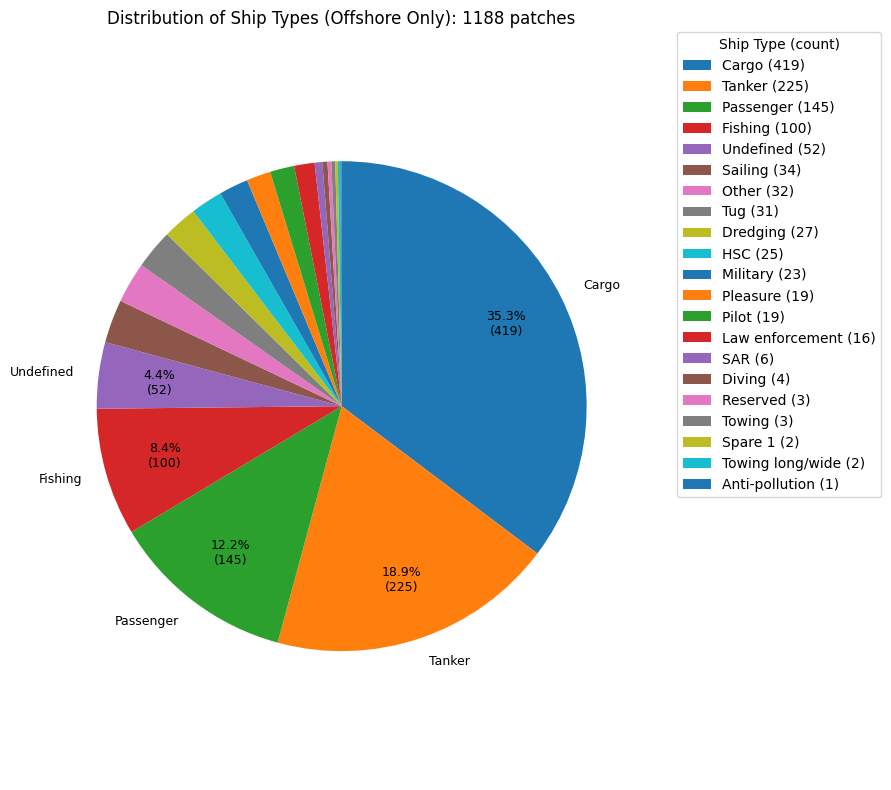

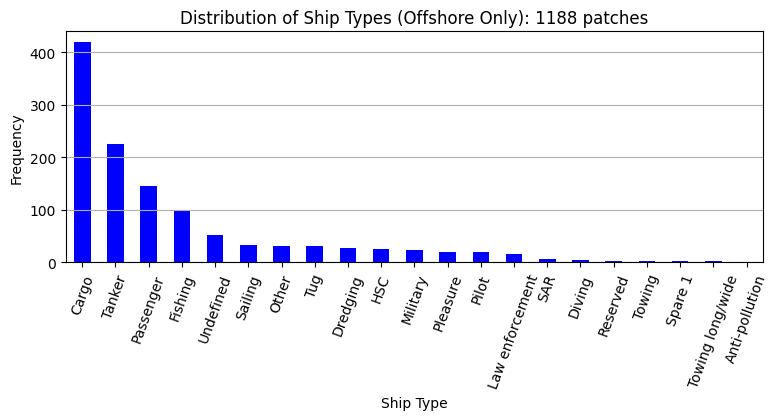

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Config: what counts as "small" (hidden on the pie, still shown in legend) ===
MIN_PCT = 3.0   # hide labels/percentages for slices smaller than this percentage

# Get counts
counts = AIS_df4['Ship type'].value_counts()
names = counts.index.to_list()
values = counts.values
total = values.sum()
pcts = values / total * 100.0

# Decide which slices are "large enough" to label on the pie
mask = pcts >= MIN_PCT

# Fallback: if none meets the threshold, label at least the largest slice
if not mask.any():
    # mark only the argmax as True
    mask[np.argmax(pcts)] = True

# Build labels for wedges: show name only for large slices
labels = [name if m else '' for name, m in zip(names, mask)]

# Autopct that shows % and count only for large slices
any_large = mask.any()
max_pct = float(pcts.max()) if len(pcts) else 0.0
EPS = 1e-9

def autopct_if_large(pct):
    # Show text only if this slice is considered "large"
    if any_large:
        if pct + EPS < MIN_PCT:
            return ''
    else:
        # Fallback case (shouldn't happen with mask fix, but kept for safety)
        if pct + EPS < max_pct:
            return ''
    val = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({val})'

fig, ax = plt.subplots(figsize=(9, 8))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct=autopct_if_large,
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    textprops={'fontsize': 9}
)

ax.set_title(f'Distribution of Ship Types (Offshore Only): {len(tif_dir4)} patches')
ax.axis('equal')  # keep it circular

# === Legend: include ALL categories, regardless of size ===
legend_labels = [f'{n} ({v})' for n, v in zip(names, values)]
ax.legend(
    wedges, legend_labels,
    title='Ship Type (count)',
    bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.
)

plt.tight_layout()

plt.figure()
AIS_df4['Ship type'].value_counts().plot(kind='bar', figsize=(9, 3), color='blue')
plt.title(f'Distribution of Ship Types (Offshore Only): {len(tif_dir4)} patches')
plt.xlabel('Ship Type')
plt.ylabel('Frequency')
plt.xticks(rotation=70)
plt.grid(axis='y')

plt.savefig(f"{Export_path}/ShipType_Distribution_OffshoreHQPatches_BarChart.jpg", dpi=400)

In [15]:
# Extract unique Ship names and their counts:

AIS_df4['Ship type'].value_counts()


Ship type
Cargo               419
Tanker              225
Passenger           145
Fishing             100
Undefined            52
Sailing              34
Other                32
Tug                  31
Dredging             27
HSC                  25
Military             23
Pleasure             19
Pilot                19
Law enforcement      16
SAR                   6
Diving                4
Reserved              3
Towing                3
Spare 1               2
Towing long/wide      2
Anti-pollution        1
Name: count, dtype: int64

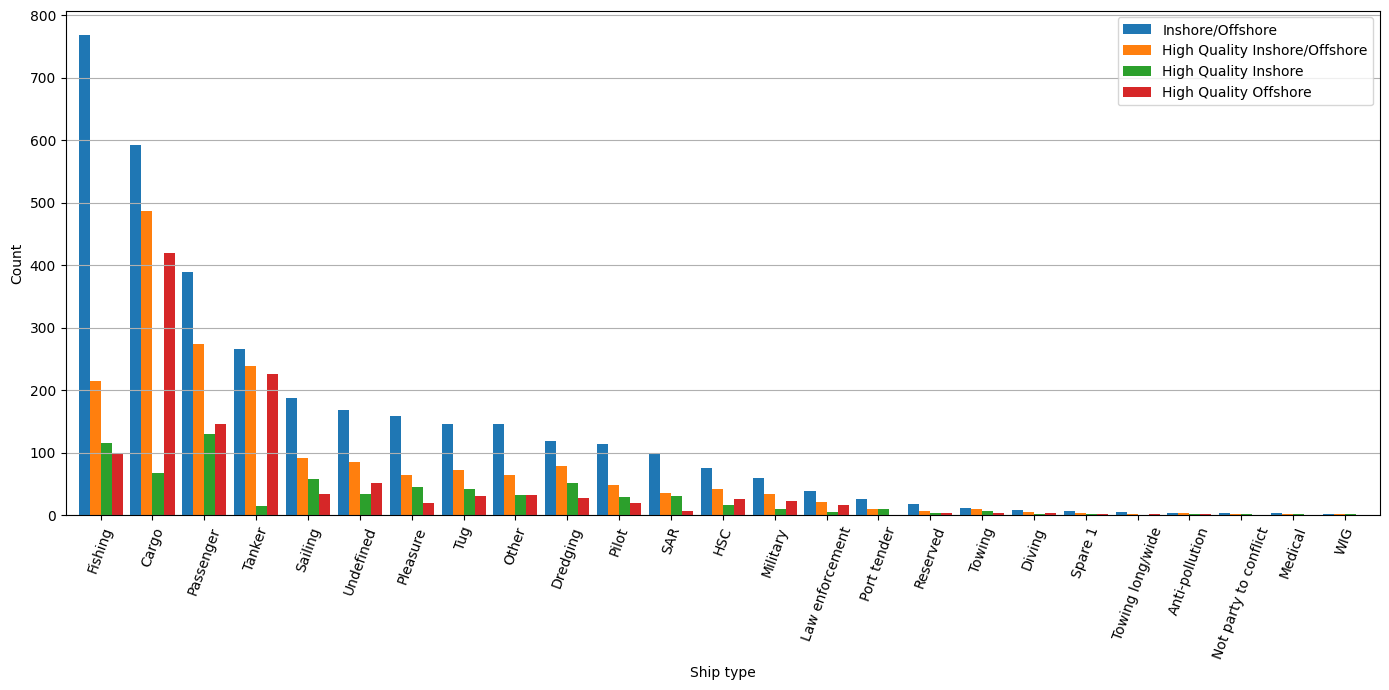

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute value counts for each dataframe
counts_df = [AIS_df['Ship type'].value_counts(),
             AIS_df2['Ship type'].value_counts(),
             AIS_df3['Ship type'].value_counts(),
             AIS_df4['Ship type'].value_counts()]

# Align both series to have the same index (ship types)
combined = pd.concat(counts_df, axis=1, keys=['Inshore/Offshore', 'High Quality Inshore/Offshore', 'High Quality Inshore', 'High Quality Offshore']).fillna(0)

# Plot grouped bar chart
ax = combined.plot(kind='bar', figsize=(14, 7), width=0.85)
# ax.set_title('Grouped Bar Chart of Ship Types')
ax.set_xlabel('Ship type')
ax.set_ylabel('Count')
plt.xticks(rotation=70)
# plt.legend(title='Source')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

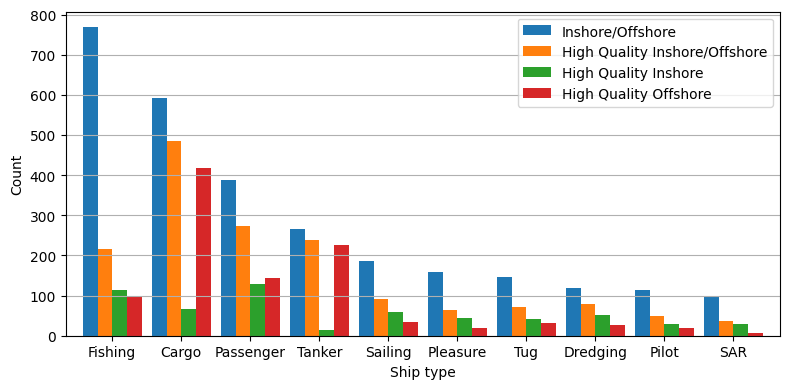

In [ ]:
df_all = [AIS_df, AIS_df2, AIS_df3, AIS_df4]
counts_df = []
for dfii in df_all:
    df_f = dfii[ (dfii['Ship type'] != 'Undefined') & (dfii['Ship type'] != 'Other') ]
    df_f.reset_index(drop=True, inplace=True)
    counts_df.append( df_f['Ship type'].value_counts() )

AIS_df4_f = AIS_df4[ (AIS_df4['Ship type'] != 'Undefined') & (AIS_df4['Ship type'] != 'Other') ]
AIS_df4_f.reset_index(drop=True, inplace=True)

AIS_df4_f['Ship type'].value_counts()

# Align both series to have the same index (ship types)
combined = pd.concat(counts_df, axis=1, keys=['Inshore/Offshore', 'High Quality Inshore/Offshore', 'High Quality Inshore', 'High Quality Offshore']).fillna(0)
combined = combined.head(10)

# Plot grouped bar chart
ax = combined.plot(kind='bar', figsize=(8, 4), width=0.85)
# ax.set_title('Grouped Bar Chart of Ship Types')
ax.set_xlabel('Ship type')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
# plt.legend(title='Source')
plt.tight_layout()
plt.grid(axis='y')

plt.savefig(f"{Export_path}/ShipType_Distribution_Grouped_BarChart_Top10.jpg", dpi=400)


## Shape Distribution

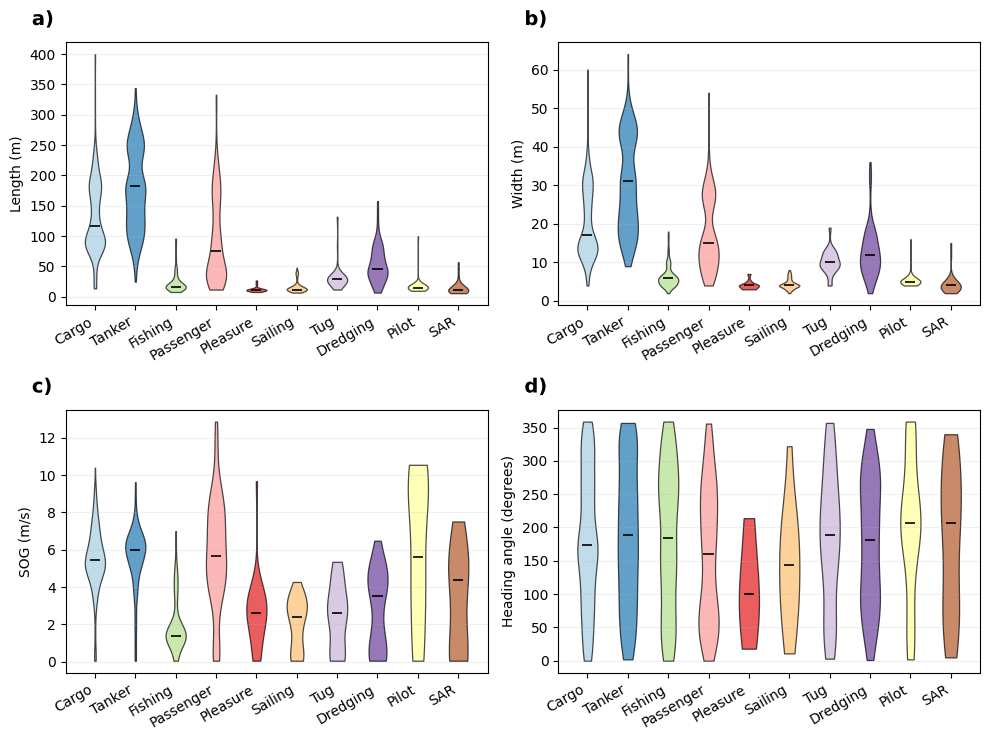

In [241]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke

classes = ['Cargo', 'Tanker', 'Fishing', 'Passenger', 'Pleasure', 'Sailing', 'Tug', 'Dredging', 'Pilot', 'SAR']

W_all = []
L_all = []
SOG_all = []
Heading_all = []
for c_ii in classes:
    AIS_dfii = AIS_df2[AIS_df2['Ship type'] == c_ii]
    W_ii0 = AIS_dfii['Width'].to_numpy()
    L_ii0 = AIS_dfii['Length'].to_numpy()
    heading_ii0  = AIS_dfii['Heading'].to_numpy()
    sog_ii0  = AIS_dfii['SOG'].to_numpy() * 0.5144444444444444  # knot to m/s
         
    W_ii = W_ii0[~np.isnan(W_ii0)]
    L_ii = L_ii0[~np.isnan(L_ii0)]
    heading_ii = heading_ii0[~np.isnan(heading_ii0)]
    sog_ii = sog_ii0[~np.isnan(sog_ii0)]
    sog_ii = sog_ii[sog_ii > 0]  # Consider only SOG > 0 m/s
    
    W_all.append(W_ii)
    L_all.append(L_ii)
    SOG_all.append(sog_ii)
    Heading_all.append(heading_ii)

# Positions and xticks shared by both figures
positions = np.arange(1, len(classes) + 1)

plot_data_all = [L_all, W_all, SOG_all, Heading_all]
plot_titles_all = [
    'Length by Ship Class (Violin Plot)',
    'Width by Ship Class (Violin Plot)',
    'SOG by Ship Class (Violin Plot)',
    'Heading angle by Ship Class (Violin Plot)'
]
y_labels = ['Length (m)', 'Width (m)', 'SOG (m/s)', 'Heading angle (degrees)']

# Color palette
cmap = plt.cm.Paired
colors = [cmap(i / max(1, len(classes) - 1)) for i in range(len(classes))]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 7.5))

cc = 0
for pdataii, ptitleii, ylabelii in zip(plot_data_all, plot_titles_all, y_labels):
    row = cc // 2
    col = cc % 2
    cc += 1

    parts = ax[row, col].violinplot(
        pdataii,
        positions=positions,
        showmeans=False,#True,
        showmedians=True,#False,
        showextrema=False
    )

    for i, body in enumerate(parts['bodies']):
        body.set_facecolor(colors[i])
        body.set_edgecolor('black')
        body.set_alpha(0.7)
        body.set_linewidth(0.9)

    # Style the median lines if present
    if 'cmedians' in parts and parts['cmedians'] is not None:
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.2)

    ax[row, col].set_xticks(positions)
    ax[row, col].set_xticklabels(classes, rotation=30, ha='right')
    ax[row, col].set_ylabel(ylabelii)
    # ax[row, col].set_title(ptitleii)
    ax[row, col].grid(axis='y', alpha=0.2)

# ---- Add subplot labels "a b c d" ----
def label_subplots(axs, labels=None, x=-0.08, y=1.05, fontsize=14, weight='bold'):
    """
    Label subplots in a grid with letters (default: a, b, c, d).
    Coordinates are in axes fraction (0..1). Adjust x/y if needed.
    """
    if labels is None:
        labels = [chr(ord('a') + i) for i in range(axs.size)]
    labels = [str(l) for l in labels]
    k = 0
    for r in range(axs.shape[0]):
        for c in range(axs.shape[1]):
            axs[r, c].text(
                x, y, labels[k],
                transform=axs[r, c].transAxes,
                fontsize=fontsize, fontweight=weight, va='bottom', ha='left',
                path_effects=[withStroke(linewidth=3, foreground='white', alpha=0.8)]
            )
            k += 1

label_subplots(ax, labels=['a)', 'b)', 'c)', 'd)'])

fig.tight_layout()
plt.savefig(f"{Export_path}/ShipType_GeometricDistribution_ViolinPlot_Top10.jpg", dpi=400)


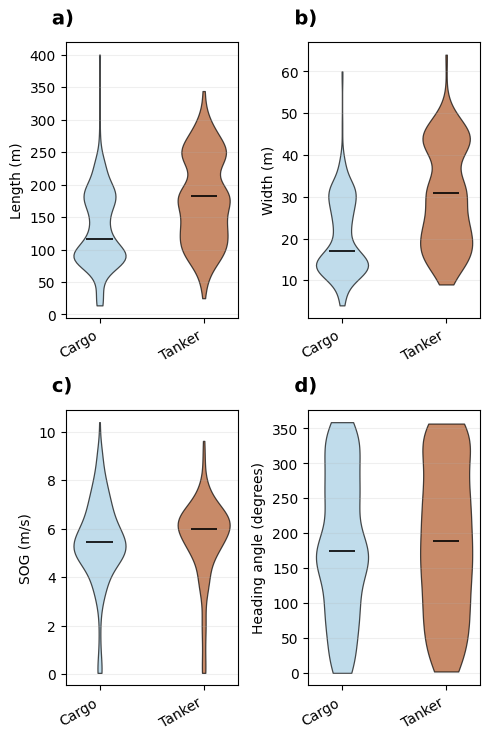

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke

classes = ['Cargo', 'Tanker']

W_all = []
L_all = []
SOG_all = []
Heading_all = []
for c_ii in classes:
    AIS_dfii = AIS_df2[AIS_df2['Ship type'] == c_ii]
    W_ii0 = AIS_dfii['Width'].to_numpy()
    L_ii0 = AIS_dfii['Length'].to_numpy()
    heading_ii0  = AIS_dfii['Heading'].to_numpy()
    sog_ii0  = AIS_dfii['SOG'].to_numpy() * 0.5144444444444444  # knot to m/s
         
    W_ii = W_ii0[~np.isnan(W_ii0)]
    L_ii = L_ii0[~np.isnan(L_ii0)]
    heading_ii = heading_ii0[~np.isnan(heading_ii0)]
    sog_ii = sog_ii0[~np.isnan(sog_ii0)]
    sog_ii = sog_ii[sog_ii > 0]  # Consider only SOG > 0 m/s
    
    W_all.append(W_ii)
    L_all.append(L_ii)
    SOG_all.append(sog_ii)
    Heading_all.append(heading_ii)

# Positions and xticks shared by both figures
positions = np.arange(1, len(classes) + 1)

plot_data_all = [L_all, W_all, SOG_all, Heading_all]
plot_titles_all = [
    'Length by Ship Class (Violin Plot)',
    'Width by Ship Class (Violin Plot)',
    'SOG by Ship Class (Violin Plot)',
    'Heading angle by Ship Class (Violin Plot)'
]
y_labels = ['Length (m)', 'Width (m)', 'SOG (m/s)', 'Heading angle (degrees)']

# Color palette
cmap = plt.cm.Paired
colors = [cmap(i / max(1, len(classes) - 1)) for i in range(len(classes))]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(5, 7.5))

cc = 0
for pdataii, ptitleii, ylabelii in zip(plot_data_all, plot_titles_all, y_labels):
    row = cc // 2
    col = cc % 2
    cc += 1

    parts = ax[row, col].violinplot(
        pdataii,
        positions=positions,
        showmeans=False,#True,
        showmedians=True,#False,
        showextrema=False
    )

    for i, body in enumerate(parts['bodies']):
        body.set_facecolor(colors[i])
        body.set_edgecolor('black')
        body.set_alpha(0.7)
        body.set_linewidth(0.9)

    # Style the median lines if present
    if 'cmedians' in parts and parts['cmedians'] is not None:
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.2)

    ax[row, col].set_xticks(positions)
    ax[row, col].set_xticklabels(classes, rotation=30, ha='right')
    ax[row, col].set_ylabel(ylabelii)
    # ax[row, col].set_title(ptitleii)
    ax[row, col].grid(axis='y', alpha=0.2)

# ---- Add subplot labels "a b c d" ----
def label_subplots(axs, labels=None, x=-0.08, y=1.05, fontsize=14, weight='bold'):
    """
    Label subplots in a grid with letters (default: a, b, c, d).
    Coordinates are in axes fraction (0..1). Adjust x/y if needed.
    """
    if labels is None:
        labels = [chr(ord('a') + i) for i in range(axs.size)]
    labels = [str(l) for l in labels]
    k = 0
    for r in range(axs.shape[0]):
        for c in range(axs.shape[1]):
            axs[r, c].text(
                x, y, labels[k],
                transform=axs[r, c].transAxes,
                fontsize=fontsize, fontweight=weight, va='bottom', ha='left',
                path_effects=[withStroke(linewidth=3, foreground='white', alpha=0.8)]
            )
            k += 1

label_subplots(ax, labels=['a)', 'b)', 'c)', 'd)'])

fig.tight_layout()
plt.savefig(f"{Export_path}/ShipType_GeometricDistribution_ViolinPlot_CargoTanker.jpg", dpi=400)


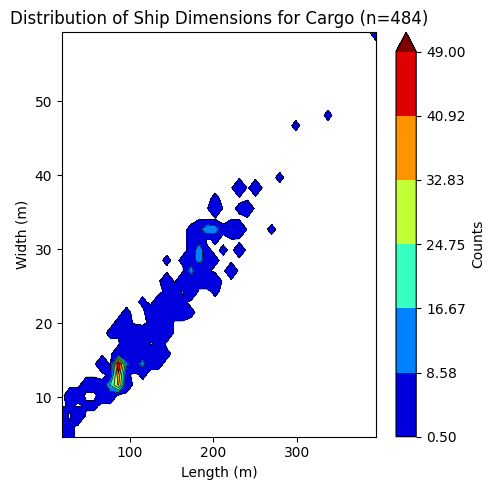

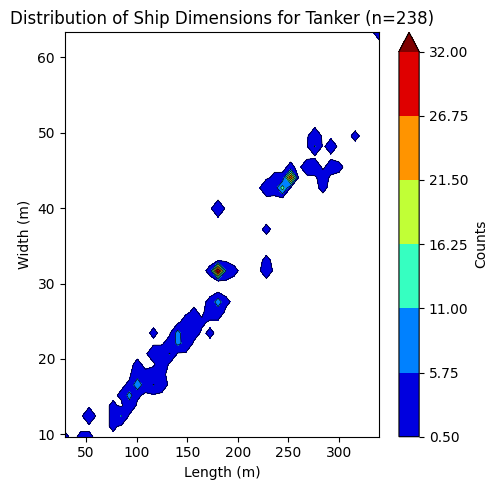

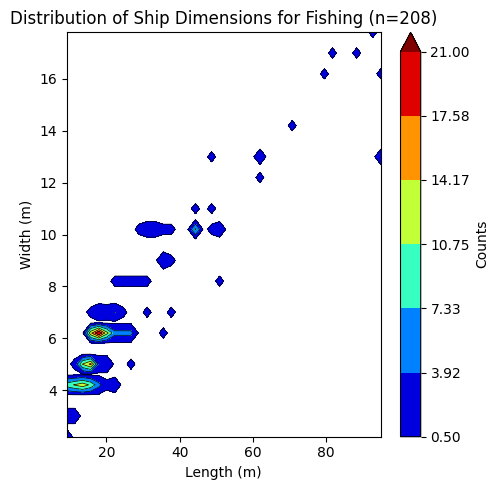

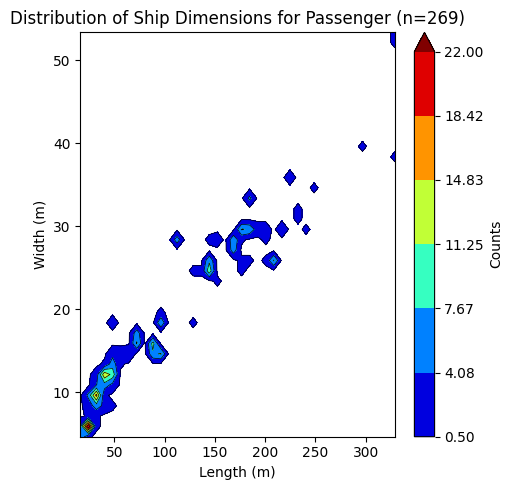

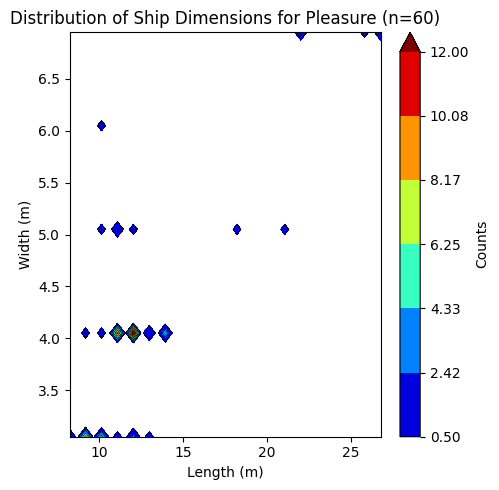

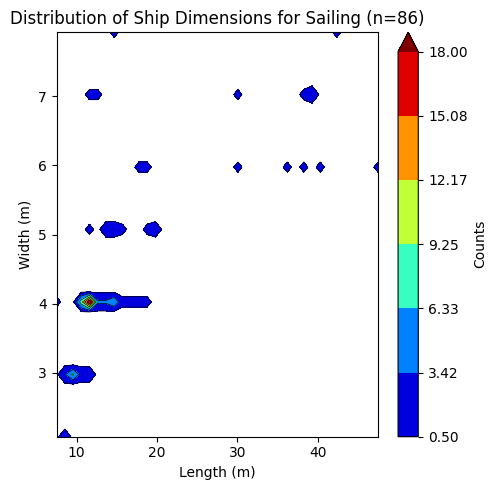

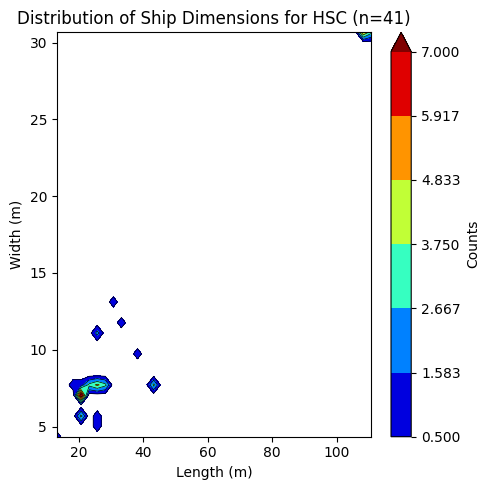

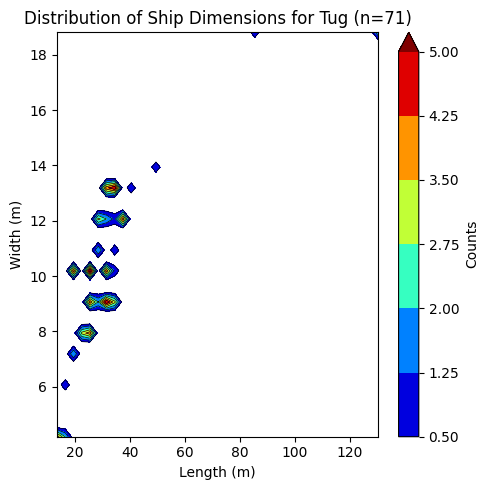

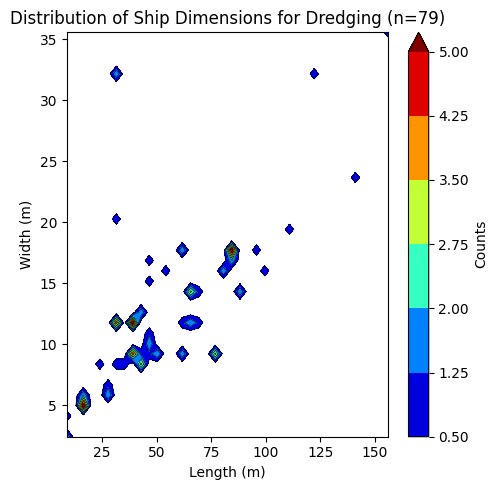

In [ ]:
classes = ['Cargo', 'Tanker', 'Fishing', 'Passenger', 'Pleasure', 'Sailing', 'HSC', 'Tug', 'Dredging']
minW = np.nanmin(AIS_df2['Width'].to_numpy())
maxW = np.nanmax(AIS_df2['Width'].to_numpy())
minL = np.nanmin(AIS_df2['Length'].to_numpy())
maxL = np.nanmax(AIS_df2['Length'].to_numpy())

for c_ii in classes:
    AIS_dfii = AIS_df2[AIS_df2['Ship type']==c_ii]
    W_ii0 = AIS_dfii['Width'].to_numpy()
    L_ii0 = AIS_dfii['Length'].to_numpy()
    mask = (~np.isnan(W_ii0)) & (~np.isnan(L_ii0))
    W_ii = W_ii0[mask]
    L_ii = L_ii0[mask]
    
    if len(L_ii) == 0:
        # skip classes with no valid samples
        continue

    plt.figure(figsize=(5, 5))

    # Compute 2D histogram
    bins = 40
    H, xedges, yedges = np.histogram2d(L_ii, W_ii, bins=bins)
    # histogram2d returns array with shape (x_bins, y_bins); transpose for plotting
    H = H.T

    # Define levels for contours (avoid level 0)
    maxH = H.max()
    if maxH <= 0:
        levels = [0.5]
    else:
        levels = np.linspace(0.5, maxH, 7)

    # Plot filled contours and contour lines
    X, Y = np.meshgrid(xedges, yedges)
    cf = plt.contourf(X[:-1, :-1] + np.diff(xedges)/2.0, Y[:-1, :-1] + np.diff(yedges)/2.0, H, levels=levels, cmap='jet', extend='max')
    c = plt.contour(X[:-1, :-1] + np.diff(xedges)/2.0, Y[:-1, :-1] + np.diff(yedges)/2.0, H, levels=levels, colors='k', linewidths=0.5)

    plt.colorbar(cf, label='Counts')
    plt.xlabel('Length (m)')
    plt.ylabel('Width (m)')
    plt.title(f'Distribution of Ship Dimensions for {c_ii} (n={len(L_ii)})')
    plt.tight_layout()
    plt.show()

    

NameError: name 'plot_cov_ellipse' is not defined

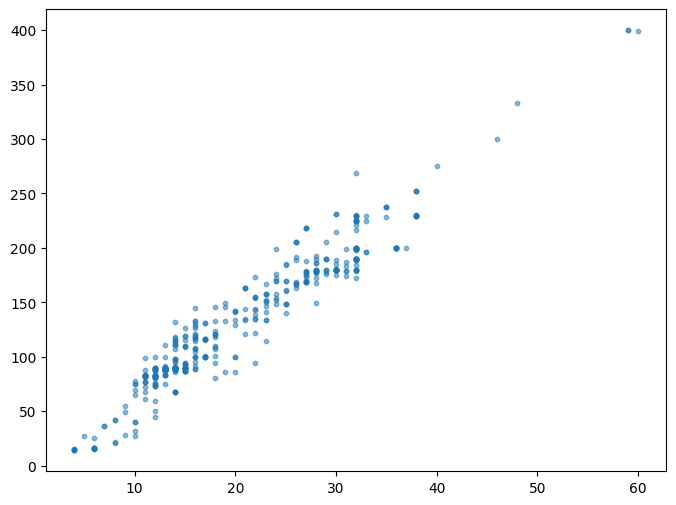

In [181]:
# Plot all samples and their covariance ellipses
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']


for ii, c_ii in enumerate(classes):
    AIS_dfii = AIS_df2[AIS_df2['Ship type']==c_ii]
    W_ii0 = AIS_dfii['Width'].to_numpy()
    L_ii0 = AIS_dfii['Length'].to_numpy()
    W_ii = W_ii0[(np.isnan(W_ii0)==False) & (np.isnan(L_ii0)==False)]
    L_ii = L_ii0[(np.isnan(W_ii0)==False) & (np.isnan(L_ii0)==False)]
    ax.scatter(W_ii, L_ii, s=10, label=f'Sample {ii+1}', alpha=0.5)
    plot_cov_ellipse(np.concatenate([[W_ii], [L_ii]]).T, ax)

ax.set_title('2D Gaussian Ellipse Distributions for 5 Samples')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1312770/2482448554.py:21: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = [np.random.multivariate_normal(mean=np.random.rand(2)*10,


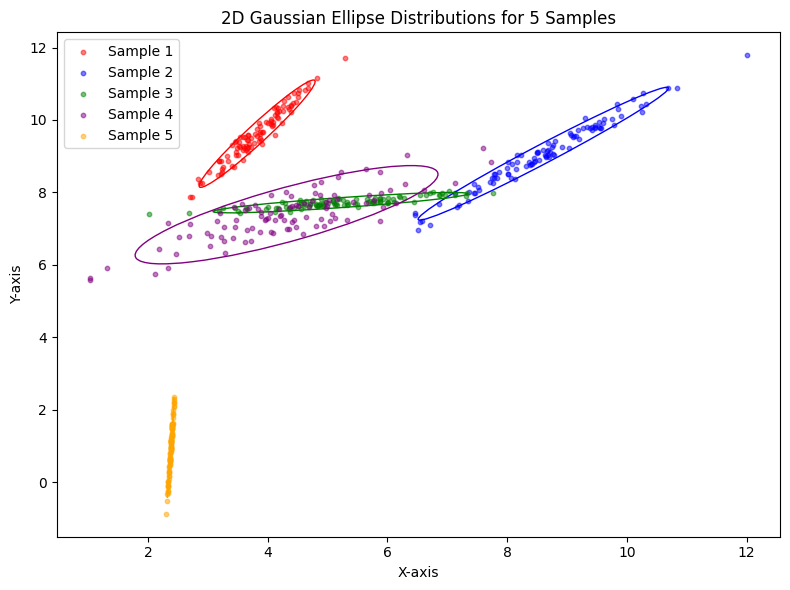

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Function to draw an ellipse representing the covariance of a 2D sample
def plot_cov_ellipse(sample, ax, n_std=2.0, facecolor='none', edgecolor='black', **kwargs):
    
    mean = np.mean(sample, axis=0)
    cov = np.cov(sample, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=theta,
                      facecolor=facecolor, edgecolor=edgecolor, **kwargs)
    ax.add_patch(ellipse)

# Generate 5 random 2D samples
np.random.seed(42)
samples = [np.random.multivariate_normal(mean=np.random.rand(2)*10,
                                         cov=np.random.rand(2,2) @ np.random.rand(2,2).T,
                                         size=100) for _ in range(5)]

# Plot all samples and their covariance ellipses
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i, sample in enumerate(samples):
    # mean = np.mean(sample, axis=0)
    # cov = np.cov(sample, rowvar=False)
    ax.scatter(sample[:, 0], sample[:, 1], s=10, color=colors[i], label=f'Sample {i+1}', alpha=0.5)
    plot_cov_ellipse(sample, ax, edgecolor=colors[i])

ax.set_title('2D Gaussian Ellipse Distributions for 5 Samples')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()
plt.tight_layout()
plt.show()

# Stats for Wake Patches

In [86]:

# AIS_Wake_df0 = AIS_df[AIS_df['Wake Potential'] == 1]
AIS_Wake_df0 = AIS_df[(AIS_df['Quality'] != 0) & (AIS_df['Quality'] != 9) & (AIS_df['Wake Potential'] == 1)]
AIS_Wake_df0.reset_index(drop=True, inplace=True)
print(f"Found {len(AIS_Wake_df0)} patches with potential wake signals.")

Found 1151 patches with potential wake signals.


In [176]:
# Wake Analysis:
quality0 = np.array(quality)
quality0[quality0==9]=0

wquality = AIS_df['Wake Quality'].to_list()
tif_dir_wake = [tifii for tifii,qii, wqii in zip(tif_dir, quality0, wquality) if (wqii==1 and qii !=0)]

AIS_Wake_df = AIS_df[(AIS_df['Quality'] != 0) & (AIS_df['Quality'] != 9) & (AIS_df['Wake Quality'] == 1)]
print(f"Found {len(AIS_Wake_df)} patches with visible wake out of {len(AIS_df)} offshore patches.")
AIS_Wake_df['Ship type'].value_counts()

Found 500 patches with visible wake out of 3415 offshore patches.


Ship type
Cargo              205
Tanker             114
Passenger           80
Fishing             15
Tug                 14
Pilot               11
Other               10
Dredging            10
Pleasure             9
Military             7
Law enforcement      6
HSC                  6
Undefined            4
SAR                  3
Reserved             2
Port tender          1
Towing               1
Sailing              1
Diving               1
Name: count, dtype: int64

In [179]:
Shtype = ['Cargo', 'Tanker', 'Fishing', 'Passenger', 'Tug', 'Sailing']

Ship_typeW = AIS_Wake_df['Ship type'].to_list()

for shtii in Shtype:
    tif_dir_class = [tifii for tifii, typeii in zip(tif_dir_wake, Ship_typeW) if (typeii == shtii)]
    tif_dir_class

    if not os.path.exists(f"{head_dir}Wake_HighQuality_Patches/"):
        os.mkdir(f"{head_dir}Wake_HighQuality_Patches/")
    
    copypath = f"{head_dir}Wake_HighQuality_Patches/{shtii}/"
    if not os.path.exists(copypath):
        os.mkdir(copypath)
    import shutil
    for tifii in tif_dir_class:
        filenameii = tifii.split('/')[-1]
        tifii = tifii.replace('ship_patches', 'wake_patches_uint8')
        tifii = tifii[:-4] + '_Wake_uint8.tif'

        shutil.copy2(tifii, f"{copypath}{filenameii}")

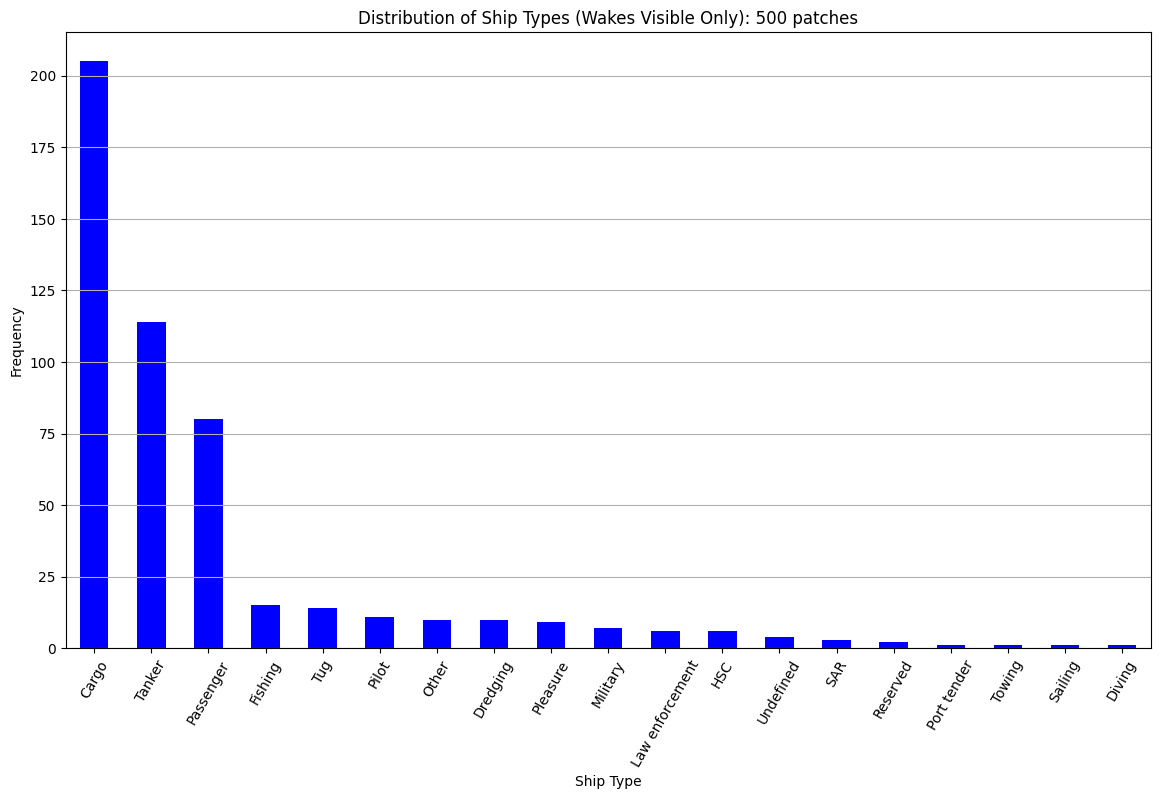

In [70]:
AIS_Wake_df['Ship type'].value_counts().plot(kind='bar', figsize=(14, 8), color='blue')
plt.title(f'Distribution of Ship Types (Wakes Visible Only): {len(AIS_Wake_df)} patches')
plt.xlabel('Ship Type')
plt.ylabel('Frequency')
plt.xticks(rotation=60)
plt.grid(axis='y')

plt.savefig(f"{Export_path}/ShipType_Distribution_Wakes_BarChart.jpg", dpi=400)

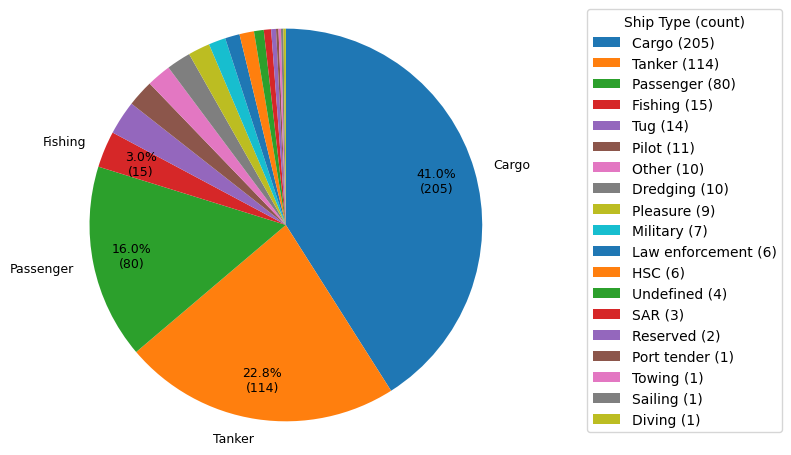

In [141]:
# === Config: what counts as "small" (hidden on the pie, still shown in legend) ===
MIN_PCT = 3.0   # hide labels/percentages for slices smaller than this percentage

# Get counts
counts = AIS_Wake_df['Ship type'].value_counts()
names = counts.index.to_list()
values = counts.values
total = values.sum()
pcts = values / total * 100.0

# Decide which slices are "large enough" to label on the pie
mask = pcts >= MIN_PCT

# Fallback: if none meets the threshold, label at least the largest slice
if not mask.any():
    # mark only the argmax as True
    mask[np.argmax(pcts)] = True

# Build labels for wedges: show name only for large slices
labels = [name if m else '' for name, m in zip(names, mask)]

# Autopct that shows % and count only for large slices
any_large = mask.any()
max_pct = float(pcts.max()) if len(pcts) else 0.0
EPS = 1e-9

def autopct_if_large(pct):
    # Show text only if this slice is considered "large"
    if any_large:
        if pct + EPS < MIN_PCT:
            return ''
    else:
        # Fallback case (shouldn't happen with mask fix, but kept for safety)
        if pct + EPS < max_pct:
            return ''
    val = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({val})'

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct=autopct_if_large,
    startangle=90,
    counterclock=False,
    pctdistance=0.8,
    textprops={'fontsize': 9}
)

# ax.set_title(f'Distribution of Ship Types (Wakes Visible Only): {len(AIS_Wake_df)} patches')
ax.axis('equal')  # keep it circular

# === Legend: include ALL categories, regardless of size ===
legend_labels = [f'{n} ({v})' for n, v in zip(names, values)]
ax.legend(
    wedges, legend_labels,
    title='Ship Type (count)',
    bbox_to_anchor=(1.06, 1), loc='upper left', borderaxespad=0.
)

plt.tight_layout()
plt.savefig(f"{Export_path}/ShipType_Distribution_Wakes_PieChart.jpg", dpi=400, bbox_inches='tight')


In [89]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 51.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [cartopy]m1/2 [cartopy]
Note: you may need to restart the kernel to use updated packages.
